In [1]:
# Q1 : Importation des bibliothèques
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
# Q2 : Chargement et aperçu des données
df = pd.read_csv('50_Startups.csv')  # ⚠️ Renomme le fichier en Startups.csv si besoin
display(df.head())  # Affiche les 5 premières lignes
print(f"✅ Shape : {df.shape} | Colonnes : {list(df.columns)}")

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


✅ Shape : (51, 5) | Colonnes : ['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']


In [3]:
# Q3 : Vérification et suppression des doublons
doublons = df[df.duplicated(keep=False)]  # Affiche TOUTES les lignes dupliquées (pas seulement la 2e)
print("Lignes dupliquées trouvées :")
display(doublons)

df = df.drop_duplicates()  # Supprime les doublons (garde la 1re occurrence)
print(f"✅ Shape après suppression : {df.shape}")

Lignes dupliquées trouvées :


,R&D Spend,Administration,Marketing Spend,State,Profit
46,1315.46,115816.21,297114.46,Florida,49490.75
50,1315.46,115816.21,297114.46,Florida,49490.75


✅ Shape après suppression : (50, 5)


In [4]:
# Q4 : Vérification des valeurs manquantes
missing = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing[missing > 0])  # N'affiche que les colonnes avec des manquants

if missing.sum() == 0:
    print("✅ Aucune valeur manquante dans le dataset.")

Valeurs manquantes par colonne :
Series([], dtype: int64)
✅ Aucune valeur manquante dans le dataset.


In [5]:
# Q5 : Statistiques descriptives sur les colonnes numériques
print("=== Statistiques Descriptives ===")
display(df.describe())

=== Statistiques Descriptives ===


,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [6]:
# Q6 : Liste des noms des colonnes
colonnes = df.columns.tolist()
print("Noms des colonnes :", colonnes)

Noms des colonnes : ['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']


In [7]:
# Q7 : Aperçu de la structure, types de données et vérification des manquants
print("=== Info() ===")
df.info()  # Affiche le nombre de lignes, colonnes, types (int/float/object) et mémoire utilisée

print("\n=== Types de données ===")
print(df.dtypes)  # Liste précise des types par colonne

print("\n=== Vérification rapide des manquants ===")
print(df.isnull().any())  # Retourne True si une colonne contient au moins un NaN

=== Info() ===
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB

=== Types de données ===
R&D Spend          float64
Administration     float64
Marketing Spend    float64
State                  str
Profit             float64
dtype: object

=== Vérification rapide des manquants ===
R&D Spend          False
Administration     False
Marketing Spend    False
State              False
Profit             False
dtype: bool


In [9]:
# Q8 : Quels sont les états où les dépenses R&D sont nulles ?
# rd_nul = df[df['R&D Spend'] == 0]
# print("Startups avec R&D Spend = 0 :")
# display(rd_nul[['R&D Spend', 'State', 'Profit']])

# # Pour répondre précisément à la question :
# etats_sans_rd = rd_nul['State'].unique()
# print(f"\nÉtats concernés : {list(etats_sans_rd)}")
df.loc[df['R&D Spend'] == 0, ['State']]

,State
47,California
49,California


In [10]:
# Q9 : Combien de startups n'ont pas investi en R&D (R&D Spend = 0) ?
nb_sans_rd = df[df['R&D Spend'] == 0].shape[0]
print(f"Nombre de startups avec R&D Spend = 0 : {nb_sans_rd}")

# Optionnel : Afficher ces lignes pour vérification
display(df[df['R&D Spend'] == 0][['R&D Spend', 'State', 'Profit']])

Nombre de startups avec R&D Spend = 0 : 2


,R&D Spend,State,Profit
47,0.0,California,42559.73
49,0.0,California,14681.40


In [13]:
# Q10 : Normalisation des colonnes numériques (R&D, Admin, Marketing)
from sklearn.preprocessing import MinMaxScaler

# On sélectionne uniquement les colonnes numériques à normaliser (hors State et Profit)
cols_numeriques = ['R&D Spend', 'Administration', 'Marketing Spend']

scaler = MinMaxScaler()
df[cols_numeriques] = scaler.fit_transform(df[cols_numeriques])

print("✅ Données numériques normalisées (moyenne ≈ 0, écart-type ≈ 1)")
display(df.head())

✅ Données numériques normalisées (moyenne ≈ 0, écart-type ≈ 1)


,R&D Spend,Administration,Marketing Spend,State,Profit
0,1.000000,0.651744,1.000000,New York,192261.83
1,0.983359,0.761972,0.940893,California,191792.06
2,0.927985,0.379579,0.864664,Florida,191050.39
3,0.873136,0.512998,0.812235,New York,182901.99
4,0.859438,0.305328,0.776136,Florida,166187.94


In [14]:
# Q11 : Quelle est la moyenne des dépenses pour la recherche et le développement ?
moyenne_rd = df['R&D Spend'].mean()
print(f"Moyenne des dépenses R&D : {moyenne_rd:.2f}")

Moyenne des dépenses R&D : 0.45


In [16]:
# Q12 : Extraire la valeur au-dessus de laquelle se situent 75% des dépenses R&D
q3_rd = df['R&D Spend'].quantile(0.25)
print(f"Valeur du 3ème quartile (Q3) des dépenses R&D : {q3_rd:.4f}")

Valeur du 3ème quartile (Q3) des dépenses R&D : 0.2415


In [18]:
# Q13 : Calculer l’écart interquartile EI = Q3 – Q1 pour les dépenses R&D
q1_rd = df['R&D Spend'].quantile(0.25)
ei_rd = q3_rd - q1_rd
print(f"Q1 : {q1_rd:.4f}")
print(f"Q3 : {q3_rd:.4f}")
print(f"Écart Interquartile (EI) : {ei_rd:.4f}")

Q1 : 0.2415
Q3 : 0.2415
Écart Interquartile (EI) : 0.0000


In [19]:
# Q14 : Quel est le pourcentage des startups ayant des profits supérieurs à la moyenne de tous les profits ?
moyenne_profit = df['Profit'].mean()
nb_sup_moyenne = df[df['Profit'] > moyenne_profit].shape[0]
total_startups = df.shape[0]
pourcentage = (nb_sup_moyenne / total_startups) * 100

print(f"Moyenne des profits : {moyenne_profit:.2f}")
print(f"Nombre de startups avec profit > moyenne : {nb_sup_moyenne}")
print(f"Pourcentage : {pourcentage:.2f}%")

Moyenne des profits : 112012.64
Nombre de startups avec profit > moyenne : 21
Pourcentage : 42.00%


In [20]:
# Q15 : Quels descripteurs contiennent des valeurs aberrantes ?
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

numeric_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']
outliers_info = {}

for col in numeric_cols:
    outliers = detect_outliers_iqr(df, col)
    if len(outliers) > 0:
        print(f"⚠️ Outliers trouvés dans '{col}' : {len(outliers)} observations")
        outliers_info[col] = len(outliers)
    else:
        print(f"✅ Aucun outlier dans '{col}'")

✅ Aucun outlier dans 'R&D Spend'
✅ Aucun outlier dans 'Administration'
✅ Aucun outlier dans 'Marketing Spend'
⚠️ Outliers trouvés dans 'Profit' : 1 observations


Text(0.5, 1.0, 'Boxplot des variables numériques')

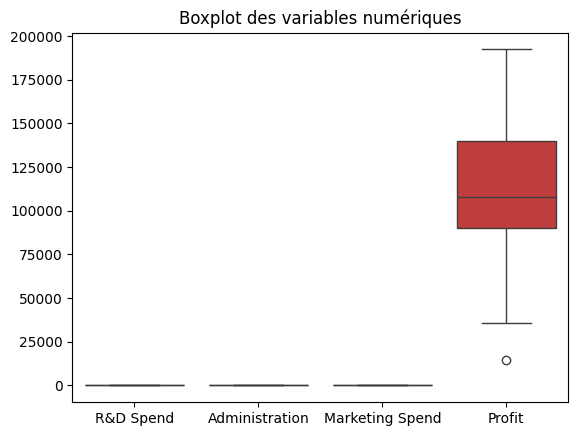

In [24]:
sns.boxplot(data=df,orient = 'v')
plt.title("Boxplot des variables numériques")

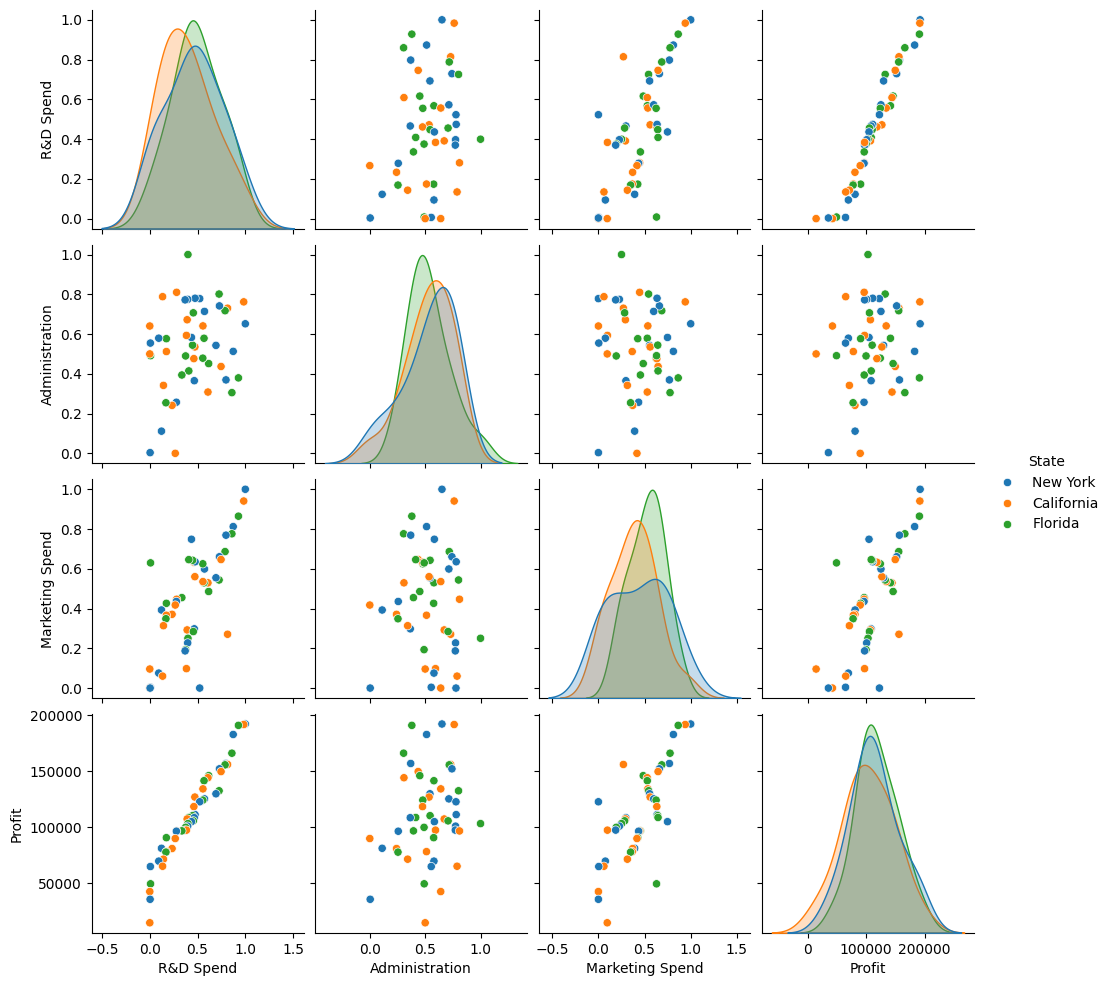

In [25]:
sns.pairplot(df, vars=numeric_cols, hue='State')

In [26]:
    # Q17 : Coefficient de corrélation de Pearson entre Marketing Spend et Profit
corr_pearson = df['Marketing Spend'].corr(df['Profit'])
print(f"Corrélation de Pearson (Marketing Spend vs Profit) : {corr_pearson:.4f}")

Corrélation de Pearson (Marketing Spend vs Profit) : 0.7478
